Objective

The objective of this notebook is to train and compare multiple regression models for crop yield prediction. Each model will be evaluated using standard regression metrics to identify the best-performing algorithm.

Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

Load Train-Test Data

In [3]:
X_train = pd.read_csv("../data/X_train_scaled.csv")
X_test = pd.read_csv("../data/X_test_scaled.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

Verify Dataset

In [4]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(15751, 5)
(3938, 5)
(15751,)
(3938,)


Create Regression Models

In [9]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "AdaBoost": AdaBoostRegressor(
        random_state=42
    ),

    "Support Vector Regressor": SVR()

}

Train Models and Evaluate

In [10]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    results.append({

        "Model": name,

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2 Score": r2

    })

print("Training Completed Successfully!")


Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training AdaBoost...
Training Support Vector Regressor...
Training Completed Successfully!


Create Results Table

In [11]:
results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.527390,0.597388,0.772909,0.778968
1,Decision Tree,0.160437,0.117895,0.343359,0.956379
2,Random Forest,0.119928,0.057332,0.239441,0.978787
3,Gradient Boosting,0.280346,0.174369,0.417575,0.935484
4,AdaBoost,1.453945,2.392615,1.546808,0.114740
5,Support Vector Regressor,0.280287,0.228116,0.477615,0.915598


Sort by Best R² Score

In [12]:
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest,0.119928,0.057332,0.239441,0.978787
1,Decision Tree,0.160437,0.117895,0.343359,0.956379
2,Gradient Boosting,0.280346,0.174369,0.417575,0.935484
3,Support Vector Regressor,0.280287,0.228116,0.477615,0.915598
4,Linear Regression,0.527390,0.597388,0.772909,0.778968
5,AdaBoost,1.453945,2.392615,1.546808,0.114740


Visualize Model Performance (R² Score)

C:\Users\Ranjana\AppData\Local\Temp\ipykernel_17460\850501748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


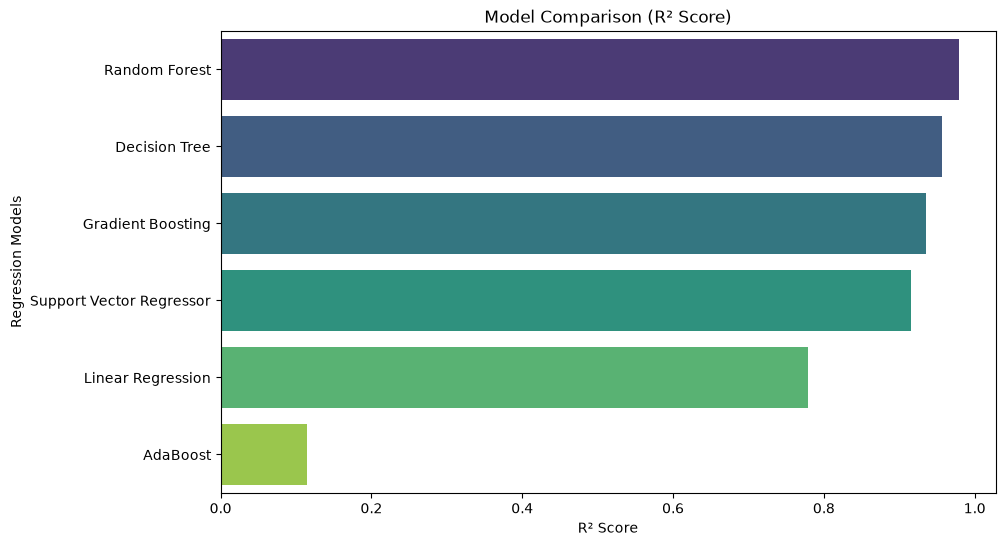

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Model",
    palette="viridis"
)

plt.title("Model Comparison (R² Score)")
plt.xlabel("R² Score")
plt.ylabel("Regression Models")

plt.show()

Compare RMSE

C:\Users\Ranjana\AppData\Local\Temp\ipykernel_17460\2939869071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


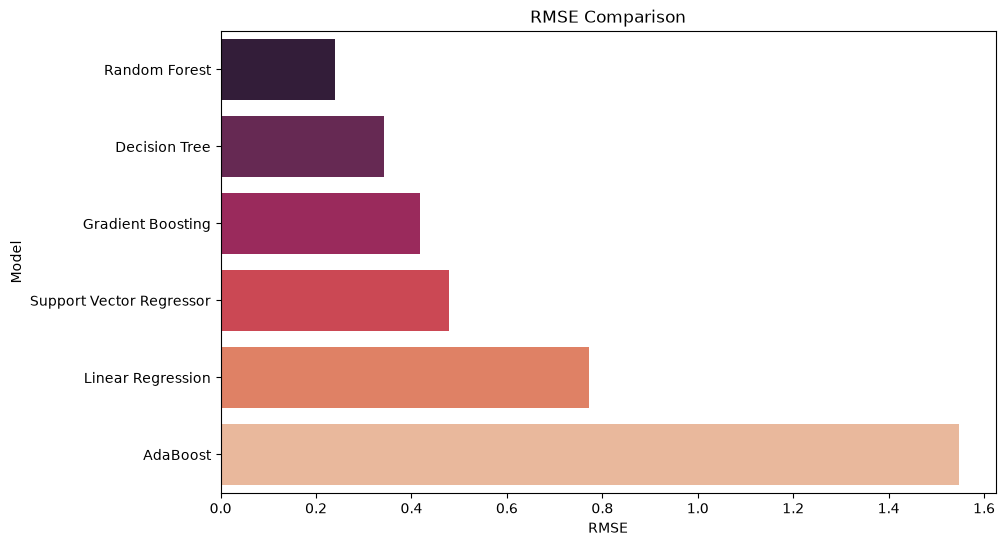

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model",
    palette="rocket"
)

plt.title("RMSE Comparison")

plt.show()

Best Model

In [16]:
best_model = results_df.iloc[0]

print("Best Model")

print(best_model)

Best Model
Model       Random Forest
MAE              0.119928
MSE              0.057332
RMSE             0.239441
R2 Score         0.978787
Name: 0, dtype: object


Train Best Model Again

In [17]:
best_rf = RandomForestRegressor(
    random_state=42
)

best_rf.fit(X_train, y_train)

pred = best_rf.predict(X_test)

Actual vs Predicted Plot

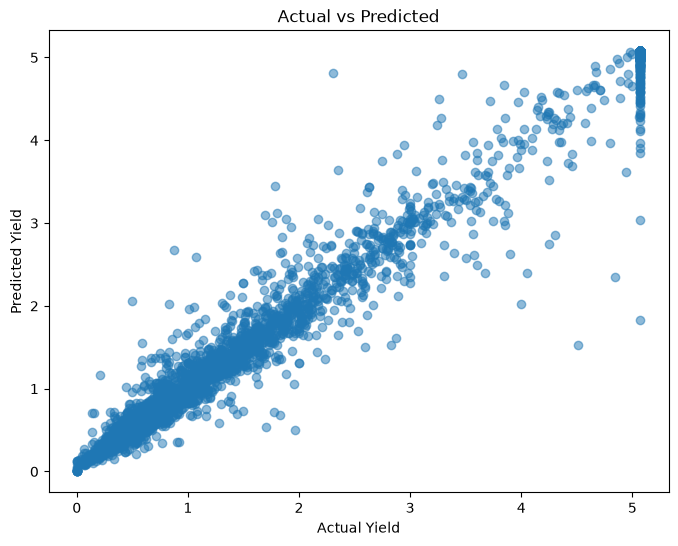

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.5
)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted")

plt.show()

Residual Plot

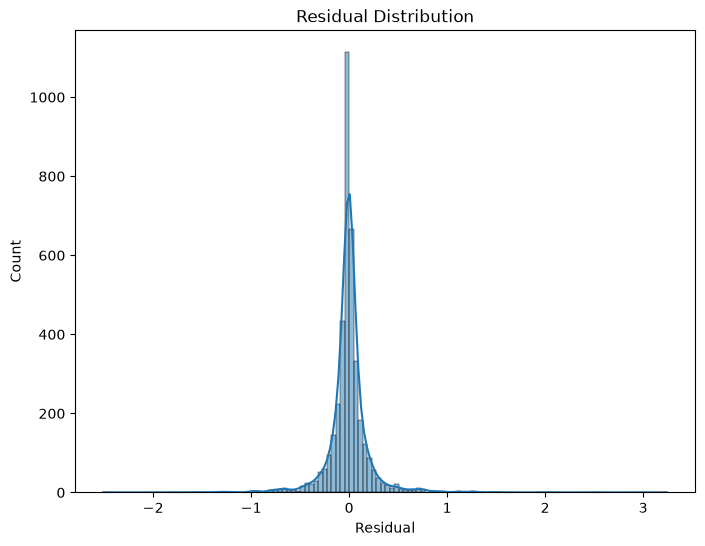

In [19]:
residuals = y_test - pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

Feature Importance (Random Forest)

In [20]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Production,0.469852
1,Area,0.292626
2,Season,0.151750
3,Fertilizer,0.047700
4,Fertilizer_per_Area,0.038072


Plot Feature Importance

C:\Users\Ranjana\AppData\Local\Temp\ipykernel_17460\1431537818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


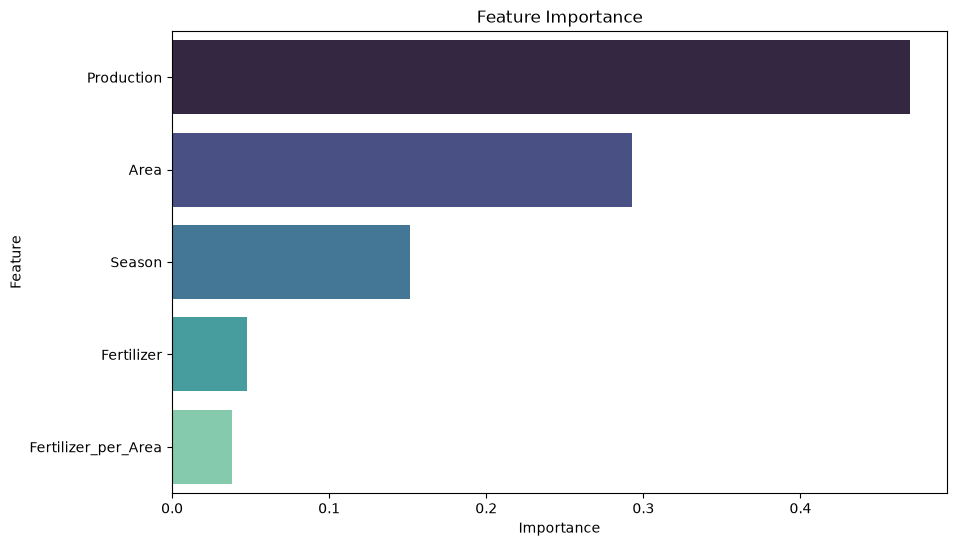

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="mako"
)

plt.title("Feature Importance")

plt.show()

Display Final Comparison Table

In [22]:
print(results_df)

                      Model       MAE       MSE      RMSE  R2 Score
0             Random Forest  0.119928  0.057332  0.239441  0.978787
1             Decision Tree  0.160437  0.117895  0.343359  0.956379
2         Gradient Boosting  0.280346  0.174369  0.417575  0.935484
3  Support Vector Regressor  0.280287  0.228116  0.477615  0.915598
4         Linear Regression  0.527390  0.597388  0.772909  0.778968
5                  AdaBoost  1.453945  2.392615  1.546808  0.114740


Save Best Model

In [24]:
import joblib
from pathlib import Path

# Current notebook location
print(Path.cwd())

# If notebook is in notebooks/
project_root = Path.cwd().parent

data_folder = project_root / "models"
data_folder.mkdir(exist_ok=True)  # Creates the folder if it doesn't exist


joblib.dump(best_rf, data_folder /"best_crop_yield_model.pkl")

print("Best Model Saved Successfully")

c:\Users\Ranjana\Crop_Yield_Prediction\notebooks
Best Model Saved Successfully


Conclusion
Trained seven regression models.
Evaluated each model using MAE, MSE, RMSE, and R² Score.
Compared model performance visually and numerically.
Identified the best-performing model.
Examined feature importance using Random Forest.
Saved the best model for future use.